In [66]:
import os
# allows us to interact with the operating system (creating folders, building file paths, etc.) which we use below to make sure our output directory exists
import numpy as np
# allows us to use numpy, which gives us fast array/numeric operations that pandas and sklearn build on top of
import pandas as pd
# allows us to use the pandas package in python which we will use for data analysis and manipulation
import matplotlib.pyplot as mattyp
import matplotlib.ticker as ticker
# allows us to use matplotlib's pyplot submodule to get a matlab-like interface, which we will use for data visualization
import seaborn as sns
# allows us to use seaborn, a plotting library built on top of matplotlib that gives us cleaner statistical visualizations (histograms, heatmaps, etc.) with less code
os.makedirs('../Visualizations', exist_ok=True)
# creates the '../Visualizations' folder if it doesn't already exist, so any files we save there later (e.g., saved figures) won't fail due to a missing directory
# exist_ok=True prevents an error from being raised if the folder is already there

In [67]:
financial_fraud = pd.read_csv('../data/PS_20174392719_1491204439457_log.csv')
# reads the csv file into a pandas DataFrame, giving us our main working dataset for the rest of the notebook

In [68]:
financial_fraud.head()
# displays the first 5 rows of the dataset so we can visually confirm the columns and data loaded correctly

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [69]:
financial_fraud.tail()
# displays the last 5 rows of the dataset, letting us check the end of the file loaded properly as well

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [70]:
financial_fraud.info()
# prints a summary of the DataFrame: column names, non-null counts, and dtypes, which we use to confirm there's no missing data and that types (int64/float64/object) are what we expect

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [71]:
financial_fraud.isnull().sum()
# Specifically checks each column and show the number on null items per column 

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

confirms no null values 

In [72]:
financial_fraud.describe().map(lambda x: f'{x:,.6f}')
# generates summary statistics (count, mean, std, min, quartiles, max) for every numeric column, giving us a first look at each feature's range and distribution


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.000000","6,362,620.000000","6,362,620.000000","6,362,620.000000","6,362,620.000000","6,362,620.000000","6,362,620.000000","6,362,620.000000"
mean,243.397246,"179,861.903549","833,883.104074","855,113.668579","1,100,701.666520","1,224,996.398202",0.001291,0.000003
std,142.331971,"603,858.231463","2,888,242.673007","2,924,048.502971","3,399,180.112969","3,674,128.942094",0.035905,0.001586
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,156.000000,"13,389.570000",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,239.000000,"74,871.940000","14,208.000000",0.000000,"132,705.665000","214,661.440000",0.000000,0.000000
75%,335.000000,"208,721.477500","107,315.175000","144,258.410000","943,036.707500","1,111,909.250000",0.000000,0.000000
max,743.000000,"92,445,516.640000","59,585,040.370000","49,585,040.370000","356,015,889.350000","356,179,278.920000",1.000000,1.000000


 After coverting from scientific notation the isFraud mean here (0.001291, or 0.1291%) matches the class imbalance check. This tells me for a binary column of 0s and 1s, the mean is mathematically identical to the proportion of 1s.

 Also the mean ($179,861.90) is a lot higher than the median($74,871.94), which tells us we have strong outlier activity and is direct evidence we'll get a right skewed histogram.

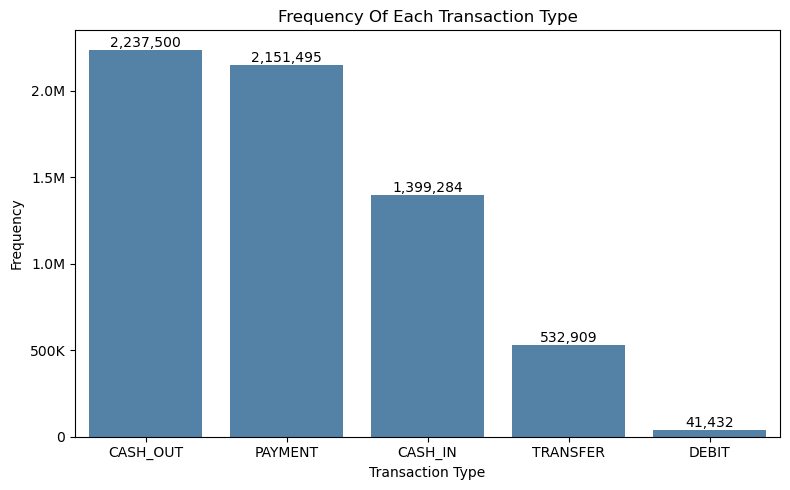

In [73]:
# ============================================================
# SECTION 1: UNIVARIATE ANALYSIS
# ------------------------------------------------------------
# Definition: Univariate analysis examines one variable at a time, 
# in isolation from all others its distribution, central tendency, 
# spread, and any anomalies.
#
# What we're looking for: Shape of the distribution (normal, skewed, bimodal), 
# presence of outliers, class imbalance in categorical columns and unexpected values (negative amounts, impossible balances).
# ============================================================

# 1a. Distribution of transaction type (categorical)
fig, ax = mattyp.subplots(figsize=(8, 5))
# creates a single figure and axes object sized 8 by 5 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below

sns.countplot(data=financial_fraud, x='type', color='steelblue', order=financial_fraud['type'].value_counts().index,ax=ax)
# draws a bar chart counting how many rows fall into each 'type' category
# order= sorts the bars from most frequent to least frequent, using value_counts to determine that order
# ax=ax tells seaborn to draw onto our explicit axes object instead of an implicit current one

# Format xy-axis ticks as readable K/M values instead of raw integers
def readable_xyvalues(num, pos):
    # a formatter function matplotlib will call once per y-axis tick
    # num is the raw tick value (e.g. 2000000), pos is its position index on the axis
    if num >= 1_000_000:
        return f'{num / 1_000_000:.1f}M'
        # if the value is a million or more, divide by a million and label it with 'M'
    elif num >= 1_000:
        return f'{num / 1_000:.0f}K'
         # if the value is a thousand or more (but under a million), divide by a thousand and label it with 'K'
    return f'{int(num)}'
    # anything smaller than 1,000 is shown as a plain integer, no letter needed

ax.yaxis.set_major_formatter(ticker.FuncFormatter(readable_yvalues)) 
# hands our formatter function to the y-axis so every tick label runs through it
# before being drawn, converting raw counts into readable K/M values  

ax.bar_label(ax.containers[0], labels=[f'{int(v.get_height()):,}' for v in ax.containers[0]])
# Add exact counts on top of each bar, formatted with thousands separators
# ax.containers[0] holds the bar objects seaborn drew; we loop through them,
# grab each bar's height (the count), and format it with comma separators for readability
ax.set_title('Frequency Of Each Transaction Type')
# sets the chart title
ax.set_xlabel('Transaction Type')
# labels the x-axis
ax.set_ylabel('Frequency')
# labels the y-axis
mattyp.tight_layout()
# automatically adjusts spacing so the title, labels, and bar-top counts don't get cut off or overlap
mattyp.savefig('../Visualizations/01univariate_type.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the noteboo

Cash_Out is the most commom transaction with over 2.2 million entries, Payment is next with 2.1 million. The least common transction type is Debit 41,432 entries, several times smaller than the top two categories.

In [74]:
# 1b. Class imbalance check for isFraud
print(financial_fraud['isFraud'].value_counts(normalize=True) * 100)
# value_counts() counts how many rows fall into each unique value of isFraud (0 or 1)
# normalize=True converts those raw counts into proportions (fractions of the whole) instead of counts
# multiplying by 100 converts those proportions into percentages, so the output reads directly.


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


Over 99.87% of entries in this dataset are not fraudulent, while only about 0.13% are confirming a severe class imbalance. This is expected for real world fraud data, where fraudulent transactions are rare relative to legitimate ones, but it means accuracy alone would be a misleading metric for evaluating a classifier here. Metrics like F1 score, which balance precision and recall, will be far more informative given how few positive (fraud) examples exist to learn from.

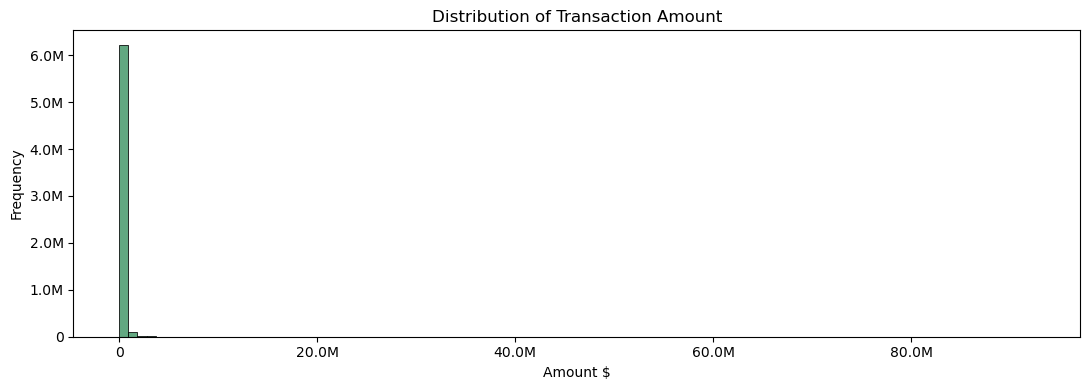

In [75]:
# 1c. Histogram of Transaction Amount
fig, ax = mattyp.subplots(figsize=(11, 4))
# creates a single figure and axes object sized 11 by 4 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.histplot(financial_fraud['amount'], bins=100, color='seagreen', ax=ax)
# draws a histogram of the raw 'amount' column, splitting the range into 100 bins
# ax=ax tells seaborn to draw onto our explicit axes object instead of an implicit current one
ax.xaxis.set_major_formatter(ticker.FuncFormatter(readable_xyvalues))
# hands our reusable formatter function to the x-axis so every tick label runs through it
# before being drawn, converting raw dollar amounts (like 20000000) into readable K/M values
ax.yaxis.set_major_formatter(ticker.FuncFormatter(readable_xyvalues))
# same formatter applied to the y-axis, since frequency counts on this dataset also run into
# the millions and would otherwise print as long unreadable raw integers
ax.set_title('Distribution of Transaction Amount')
# sets the chart title
ax.set_xlabel('Amount $')
# labels the x-axis, noting these are dollar values
ax.set_ylabel('Frequency')
# labels the y-axis
mattyp.tight_layout()
# automatically adjusts spacing so the title and axis labels don't get cut off or overlap
mattyp.savefig('../Visualizations/02histo_trans_amount.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the notebook

raw amount is too skewed to interpret visually, which is why a log transform is applied in the next step,

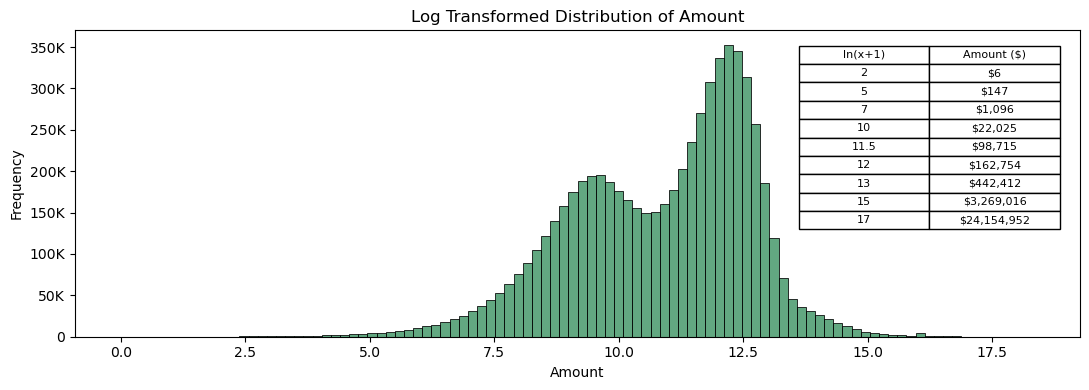

In [76]:
# 1d. Log Transformed Histogram of Transaction Amount
fig, ax = mattyp.subplots(figsize=(11, 4))
# creates a single figure and axes object sized 11 by 4 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.histplot(np.log1p(financial_fraud['amount']), bins=100, color='seagreen', ax=ax)
# plots a histogram of amount after a log1p transform (ln(x+1)), which compresses the
# extreme right-skew so the distribution's actual shape is visible instead of one bar near zero
# bins=100 controls how finely the range is divided, color sets the bar color, ax=ax draws onto our explicit axes

ax.yaxis.set_major_formatter(ticker.FuncFormatter(readable_xyvalues))
# reuses the same readable_xyvalues function defined in 1a

ax.set_title('Log Transformed Distribution of Amount')
ax.set_xlabel('Amount')
ax.set_ylabel('Frequency')
# Reference table translating log1p(x) values back to real dollar amounts
# Placed in the upper-right corner so it doesn't overlap the main distribution shape
conversion_data = [
    ['2', '$6'],
    ['5', '$147'],
    ['7', '$1,096'],
    ['10', '$22,025'],
    ['11.5', '$98,715'],
    ['12', '$162,754'],
    ['13', '$442,412'],
    ['15', '$3,269,016'],
    ['17', '$24,154,952'],
]

ref_table = ax.table(cellText=conversion_data,
                      colLabels=['ln(x+1)', 'Amount ($)'],
                      bbox=[0.72, 0.35, 0.26, 0.6],  # [x, y, width, height] in axes-relative coords
                      cellLoc='center')
ref_table.auto_set_font_size(False)
ref_table.set_fontsize(8)
mattyp.tight_layout()
mattyp.savefig('../Visualizations/03histo_logtrans_amount.png')
mattyp.show()
mattyp.close(fig)

Most of the transactions that take place are between $1,096 and $162,754. Or between x = 7-12 on our log scale. Anything outside this scale the tiny transactions under a few hundred dollars, and the rare multi million dollar transfers makes up a very small slice of total volume, even though on the raw (non log) histogram those extreme values were what visually dominated the chart because of their sheer size, not their frequency.

This is a good insight to answer future questions, the log transformation reveals that typical transaction behavior is concentrated in the four to six figure range, while the raw distribution's mean (~$180K) and especially its max (~$92M) were being pulled way up by a small number of extreme outliers.

The mean of a right skewed distribution is more than it's mode.



While preparing the log transformed histogram of amount, I noticed a small number of rows have a transaction amount of exactly $0 these had to be handled separately since a log transform can't process zero values. Before deciding how to treat them, I wanted to confirm exactly how many zero amount transactions exist in the dataset.

In [77]:
# 1e. How many zero-amount transactions exist in total?
(financial_fraud['amount'] == 0).sum()
# creates a boolean mask where each row is True if 'amount' equals exactly 0, False otherwise
# .sum() then adds up all the True values (treated as 1) to get a total count of zero-amount rows

np.int64(16)

Only 16 transactions have an amount of exactly $0 a very minuscule. Next I will investigate the type breakdown of these transactions to see if I can gain further insight. 

In [78]:
# Look at the actual rows before summarizing anything
financial_fraud[financial_fraud['amount'] == 0][['type', 'isFraud', 'oldbalanceOrg', 'newbalanceOrig']]
#financial_fraud['amount'] = 0 creates a boolean mask flagging every row where amount is exactly 0.
#financial_fraud[...] uses that mask to filter the dataframe down to only those 16 rows
#[['type', 'isFraud', 'oldbalanceOrg', 'newbalanceOrig']] selects just these four columns to display, rather than all 11, so the output is easy to scan visually for a pattern

,type,isFraud,oldbalanceOrg,newbalanceOrig
2736447,CASH_OUT,1,0.0,0.0
3247298,CASH_OUT,1,0.0,0.0
3760289,CASH_OUT,1,0.0,0.0
5563714,CASH_OUT,1,0.0,0.0
5996408,CASH_OUT,1,0.0,0.0
5996410,CASH_OUT,1,0.0,0.0
6168500,CASH_OUT,1,0.0,0.0
6205440,CASH_OUT,1,0.0,0.0
6266414,CASH_OUT,1,0.0,0.0
6281483,CASH_OUT,1,0.0,0.0


Further investigation revealed that all 16 of these 0 amount transactions are of the type CASH_OUT, and all 16 are labeled as fraud (isFraud = 1). That's a 100% fraud rate within this tiny subset, compared to the dataset's overall fraud rate of just 0.13%. This suggests that a 0 dollar CASH_OUT transaction is a strong, near certain fraud signal in this simulation rather and it's a pattern worth preserving (and potentially engineering into an explicit feature) rather than removing during cleaning.

In [79]:
# Confirm the pattern numerically
zero_amt = financial_fraud[financial_fraud['amount'] == 0]
print(zero_amt['type'].value_counts())
# prints value counts for the type column
print(zero_amt['isFraud'].value_counts())
# prints value counts for the isFraud column


type
CASH_OUT    16
Name: count, dtype: int64
isFraud
1    16
Name: count, dtype: int64


All 16 0 amount transactions are of the type CASH_OUT, and all 16 are labeled as fraud (isFraud = 1) a 100% fraud rate within this subset. This is abnormal compared to the dataset's overall fraud rate of roughly 0.13%. This confirms that amount = 0 combined with type the CASH_OUT is a strong, non random fraud pattern.

In [ ]:
# Check balances for any additional pattern
print(zero_amt[['oldbalanceOrg', 'newbalanceOrig']].describe())
# runs summary statistics (count, mean, std, min, quartiles, max) on just these two balance columns
# but only for the zero_amt subset (the 16 rows where amount == 0)
# this checks whether these transactions share any pattern in their origin account balances

       oldbalanceOrg  newbalanceOrig
count           16.0            16.0
mean             0.0             0.0
std              0.0             0.0
min              0.0             0.0
25%              0.0             0.0
50%              0.0             0.0
75%              0.0             0.0
max              0.0             0.0


All 16 zero amount, CASH_OUT fraud transactions show oldbalanceOrg and newbalanceOrig equal to exactly $0, with zero variance across every row. This means these fraudulent transactions consistently originate from accounts with no funds before or after the transaction a strong pattern.

This could represent attempted cash outs on already emptied accounts a very specific scenario. Given how consistent and rare this pattern is, it's a strong candidate for an engineered feature.

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


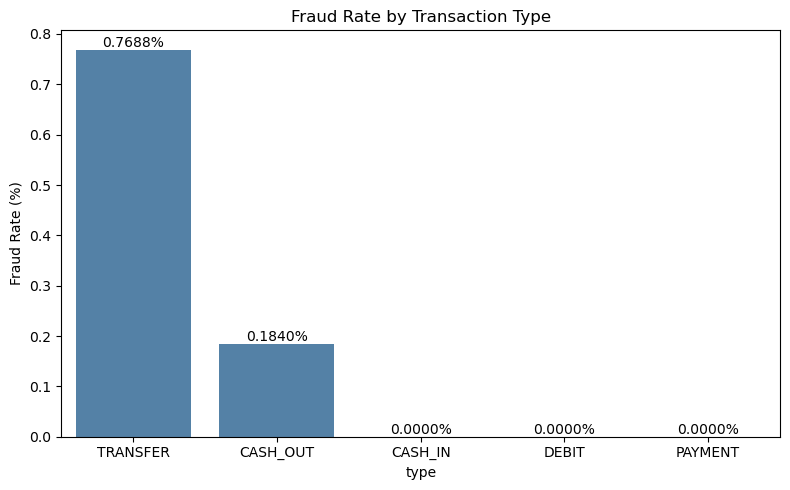

In [ ]:
# ============================================================
# SECTION 2: BIVARIATE ANALYSIS
# ------------------------------------------------------------
# Definition: Bivariate analysis looks at the relationship between exactly two variables usually a predictor against the target, but also predictor vs predictor comparisions.
# What we're looking for: Whether isFraud rates differ meaningfully across categories (e.g., does fraud cluster in certain type values?), whether numeric predictors have visibly different distributions between fraud/non-fraud, and any strong linear or nonlinear pairwise relationships between two predictors.
# ============================================================

# 2a. Fraud rate by transaction type
fraud_type = financial_fraud.groupby('type')['isFraud'].mean().sort_values(ascending=False)
# groups the data by transaction type and calculates the mean of isFraud within each group
# since isFraud is 0/1, this mean is the same as the fraud rate (proportion of fraud) for that type
# sort_values(ascending=False) orders the types from highest to lowest fraud rate
print(fraud_type)
# prints the fraud rate for each transaction type as a quick numeric check before plotting


fig, ax = mattyp.subplots(figsize=(8, 5))
# creates a single figure and axes object sized 8 by 5 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.barplot(x=fraud_type.index, y=fraud_type.values * 100, color='steelblue', ax=ax)
# draws a bar chart of fraud rate by transaction type
# x=fraud_type.index uses the type names (strings) as category labels
# y=fraud_type.values * 100 converts the fraud rate from a decimal (e.g. 0.0077) into a percentage (0.77)
# axax tells seaborn to draw onto our explicit axes object instead of an implicit current one
ax.set_title('Fraud Rate by Transaction Type')
# sets the chart title
ax.set_ylabel('Fraud Rate (%)')
# labels the y-axis, noting these values are percentages
ax.bar_label(ax.containers[0], fmt='%.4f%%')
# adds the exact fraud rate on top of each bar, formatted to 4 decimal places with a percent sign
# ax.containers[0] holds the bar objects seaborn drew, so we loop through them to label each one
mattyp.tight_layout()
# automatically adjusts spacing so the title, labels, and bar-top values don't get cut off or overlap
mattyp.savefig('../Visualizations/04bivariate_fraud_type.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the notebook


- Across the whole dataset, fraud occurs 0.1291% of the time
- Within CASH_OUT transactions specifically, the fraud rate rises to 0.1840% 1.4 times the baseline.
- Within the tiny 16 row subset of CASH_OUT transactions where amount = 0 and the origin account is already empty, the fraud rate jumps to 100% much higher then the 0.1840% for CASH_OUT transactions as a whole.
- This reinforces using 0 dollar CASH_OUT transactions as an engineering feature even though it represents very little of the actual dataset.

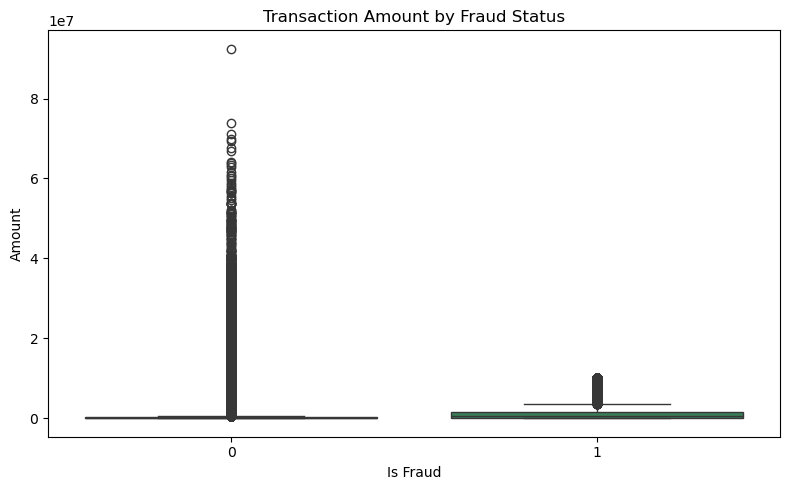

In [ ]:
# 2b. Amount distribution split by isFraud
fig, ax = mattyp.subplots(figsize=(8, 5))
# creates a single figure and axes object sized 8 by 5 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.boxplot(data=financial_fraud, x='isFraud', y='amount', color='seagreen', ax=ax)
# draws a boxplot comparing the raw amount distribution between fraud and non fraud transactions
# axax tells seaborn to draw onto our explicit axes object instead of an implicit current one
ax.set_title('Transaction Amount by Fraud Status')
# sets the chart title
ax.set_xlabel('Is Fraud')
# labels the x-axis
ax.set_ylabel('Amount')
# labels the y-axis
mattyp.tight_layout()
# automatically adjusts spacing so the title and axis labels don't get cut off or overlap
mattyp.savefig('../Visualizations/05bivariate_fraud_amount.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the notebook


The raw amount boxplot compresses both fraud and non fraud groups into a flat line near zero, because both distributions are heavily right skewed and the y-axis must stretch to fit the dataset's most extreme outliers. A log1p transform is needed here same way it was needed for the univariate amount histogram.

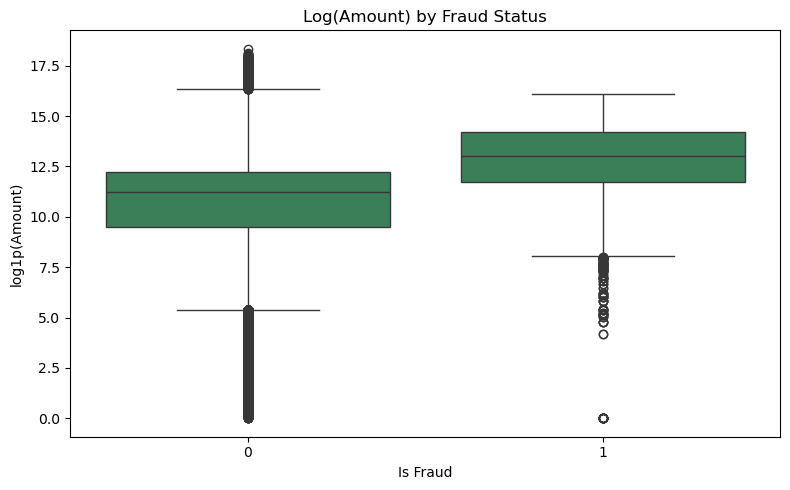

In [ ]:
# 2c. Log-scaled version since raw amount is so skewed the boxplot above is hard to read
fig, ax = mattyp.subplots(figsize=(8, 5))
# creates a single figure and axes object sized 8 by 5 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.boxplot(data=financial_fraud, x='isFraud', y=np.log1p(financial_fraud['amount']), color='seagreen', ax=ax)
# draws a boxplot comparing amount between fraud and non fraud transactions, same as 2b
# np.log1p(amount) applies a log1p transform (ln(x+1)) directly inside the plot call, compressing
# the extreme right skew so the median and IQR of each group become visible instead of squashed near zero
# axax tells seaborn to draw onto our explicit axes object instead of an implicit current one
ax.set_title('Log(Amount) by Fraud Status')
# sets the chart title
ax.set_xlabel('Is Fraud')
# labels the x-axis
ax.set_ylabel('log1p(Amount)')
# labels the y-axis, noting these are log transformed values, not raw dollar amounts
mattyp.tight_layout()
# automatically adjusts spacing so the title and axis labels don't get cut off or overlap
mattyp.savefig('../Visualizations/06bivariate_logamount_by_fraud.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the notebook


 The median amount for non-fraudulent transactions (isFraud = 0) sits around log1p ≈ 11.0; While fraudulent transactions (isFraud = 1) has a noticeably higher median around log1p ≈ 13.0; This confirms that fraud in this dataset tends to involve substantially larger transaction amounts than typical legitimate activity

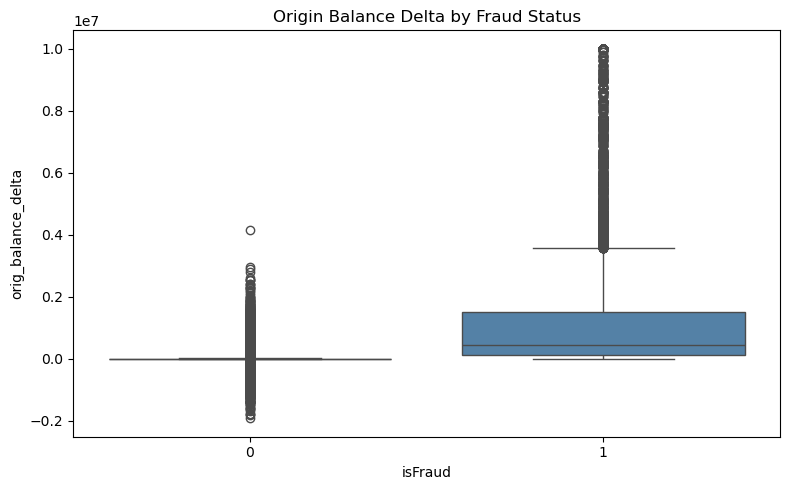

In [ ]:
# 2d. Balance discrepancy check, does the origin account zero out unusually often for fraud?
financial_fraud['orig_balance_delta'] = financial_fraud['oldbalanceOrg'] - financial_fraud['newbalanceOrig']
# creates a new column measuring how much money actually left the origin account
# a large positive value means the balance dropped significantly; a negative value means it unexpectedly increased
fig, ax = mattyp.subplots(figsize=(8, 5))
# creates a single figure and axes object sized 8 by 5 inches
# fig is the overall figure container, ax is the specific plot area we draw onto below
sns.boxplot(data=financial_fraud, x='isFraud', y='orig_balance_delta', color='steelblue', ax=ax)
# draws a boxplot comparing the distribution of orig_balance_delta between fraud and non fraud transactions
# axax tells seaborn to draw onto our explicit axes object instead of an implicit current one
ax.set_title('Origin Balance Delta by Fraud Status')
# sets the chart title
mattyp.tight_layout()
# automatically adjusts spacing so the title and axis labels don't get cut off or overlap
mattyp.savefig('../Visualizations/07bivariate_balance_delta_by_fraud.png')
# saves the figure as a PNG file into the Visualizations folder
mattyp.show()
# displays the figure in the notebook's output so it renders when the notebook is viewed
mattyp.close(fig)
# closes this specific figure object to free up memory and prevent it from
# interfering with the next plot created later in the notebook


Fraud transactions cause a larger and more consistent drop in the origin account's actual balance